In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/train.csv")

In [5]:
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


Всего в датасете 81 поле: 1 таргет и 80 фичей для обучения модели

In [12]:
df.shape[1]

81

Всего есть 3 типа данных: str, float и int

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

В некоторых полях присутствуют пропуски, ниже - доля пропусков в разных полях



In [9]:
df.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [10]:
missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
      .query("missing_count > 0")
      .sort_values("missing_pct", ascending=False)
)

missing

,missing_count,missing_pct
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


Тут надо смотреть по смыслу, некоторые пропуски несут полезную информацию сами по себе, например фичи PoolQC и MiscFeature = NaN это просто отсутствие бассейна и каких-то сторонних приколюх. NaN в этих фичах уже само по себе полезная информация, которую нельзя просто так взять и выкинуть, а вот пропуски в MasVnrArea и Electrical скорее всего никакой инфы не несут, и их надо заполнить

In [11]:
df[missing.index].dtypes

PoolQC              str
MiscFeature         str
Alley               str
Fence               str
MasVnrType          str
FireplaceQu         str
LotFrontage     float64
GarageType          str
GarageYrBlt     float64
GarageFinish        str
GarageQual          str
GarageCond          str
BsmtFinType2        str
BsmtExposure        str
BsmtFinType1        str
BsmtCond            str
BsmtQual            str
MasVnrArea      float64
Electrical          str
dtype: object

Пропуски в разных фичах будем заполнять по-разному:
1) Фичи, которые несут смысл (PoolQC / MiscFeature / etc) - заполню строковыми значениями типо "None"
2) Числовые фичи с редкими пропусками - заполню медианой
3) Категориальные фичи с редкими пропусками - заполню most frequent значением
4) Остальные категориальные и числовые фичи заполню по смыслу

Теперь посмотрим на распределение таргета, какие категориальные признаки больше на него влияют, какие-то статистики и т.д.

In [21]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

По статистике выше видим 1460 записей (ожидаемо), со средней ценой ~181k, стандартным отклонением ~79k, минимальной ценой дома в ~35k и максимальной ценой в ~755k

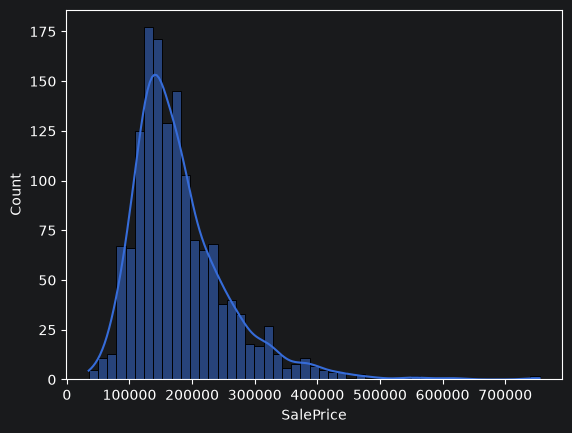

In [17]:
sns.histplot(df["SalePrice"], kde=True)
plt.show()

По графику выше - есть подозрение на логнормальное распределение данных: много относительно дешевых домов, и длинный хвост справа (дорогие дома)

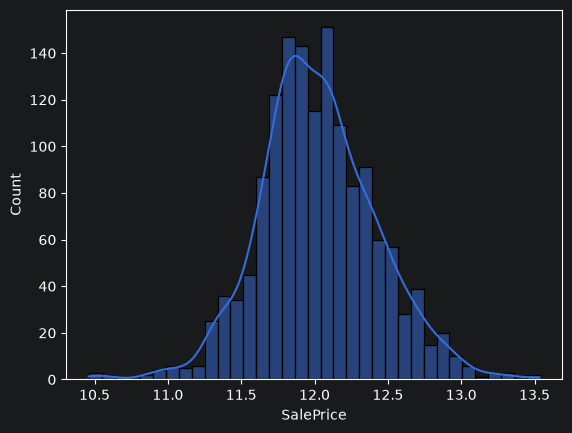

In [22]:
sns.histplot(np.log1p(df["SalePrice"]), kde=True)
plt.show()

После логарифмирования таргета распределение превратилось в нормальное - это отличный знак, значит мы можем логарифмировать таргет и работать с ним как с нормальным распределением, а предсказания возвращать через экспоненту

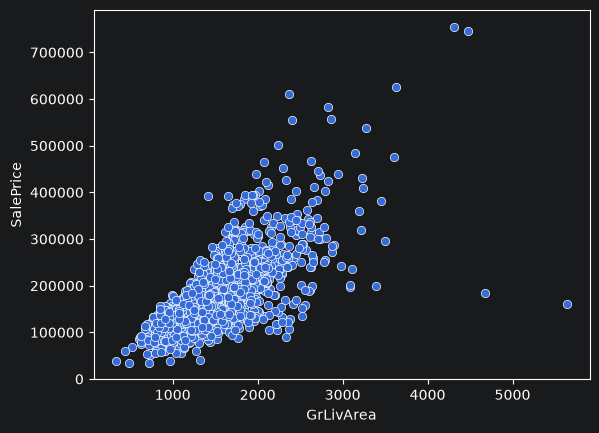

In [19]:
sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)
plt.show()

Здесь видно сильный тренд - чем больше площадь дома, тем выше его цена
Но есть пара подозрительных выбросов справа - большая площадь дома, но цена подозрительно низкая, исследуем их ниже

In [20]:
df[
    (df["GrLivArea"] > 4000) &
    (df["SalePrice"] < 300000)
][["GrLivArea", "SalePrice", "OverallQual", "Neighborhood"]]

,GrLivArea,SalePrice,OverallQual,Neighborhood
523,4676,184750,10,Edwards
1298,5642,160000,10,Edwards


In [24]:
df[df["Neighborhood"] == "Edwards"][
    ["GrLivArea", "SalePrice", "OverallQual"]
].sort_values("GrLivArea", ascending=False)

,GrLivArea,SalePrice,OverallQual
1298,5642,160000,10
523,4676,184750,10
1423,2201,274970,6
921,2200,145900,5
175,2158,243000,6
...,...,...,...
638,796,85000,5
1326,774,79000,3
1123,698,118000,5
1212,672,113000,4


Здесь видно, что эти 2 дома действительно выбиваются в районе Edwards, исключим их из train датасета впоследствии

Напоследок глянем корреляцию числовых признаков и логарифмированного таргета (т.к. работать буду с ним)

In [25]:
eda_df = df[
    ~(
        (df["GrLivArea"] > 4000) &
        (df["SalePrice"] < 300000)
    )
].copy()

y_log = np.log1p(eda_df["SalePrice"])

numeric_features = (
    eda_df
    .select_dtypes(include=np.number)
    .drop(columns=["SalePrice"])
)

correlations = (
    numeric_features
    .corrwith(y_log)
    .sort_values(key=abs, ascending=False)
)

correlations.head(20)

OverallQual     0.821405
GrLivArea       0.725211
GarageCars      0.681033
GarageArea      0.656129
TotalBsmtSF     0.647563
1stFlrSF        0.620500
FullBath        0.595899
YearBuilt       0.587043
YearRemodAdd    0.565992
GarageYrBlt     0.541638
TotRmsAbvGrd    0.537702
Fireplaces      0.491998
MasVnrArea      0.434621
BsmtFinSF1      0.392283
LotFrontage     0.372900
WoodDeckSF      0.334251
OpenPorchSF     0.325215
2ndFlrSF        0.319953
HalfBath        0.314186
LotArea         0.260544
dtype: float64

Видно сильную корреляцию таргета и фичи "Качество в целом", жилой площади, гаража, года постройки дома и т.д.

Итого к чему пришли в процессе EDA:
1) Посмотрели на распределение таргета в разрезе разных фич, определились, что в модель будем передавать логарифмированный таргет
2) Выявили выбросы, которые исключим из train датасета
3) Определились со стратегией обработки пропусков в датасете

=> Вся эта обработка будет уже частью pipeline